# Yapay Sinir Ağları(ANN) ile Rakam Tanıma
1) İş problemi (Business Problem) <br>
2) Veriyi Anlamak (Data Understanding) <br>
3) Veriyi Hazırlamak (Data Preparation) <br>
4) Modelleme (Modeling)<br>
5) Değerlendirme (Evaluation)

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical, plot_model

import matplotlib.pyplot as plt
import numpy as np

import warnings
from warnings import filterwarnings
warnings.filterwarnings("ignore", category = DeprecationWarning)
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
filterwarnings("ignore")

2024-10-16 17:34:17.601442: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# mnist veri setini yükleyip ilgili değişkenlere atalım.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 23s 2us/step


In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
x_test.shape

(10000, 28, 28)

In [8]:
num_labels = len(np.unique(y_train))
num_labels

10

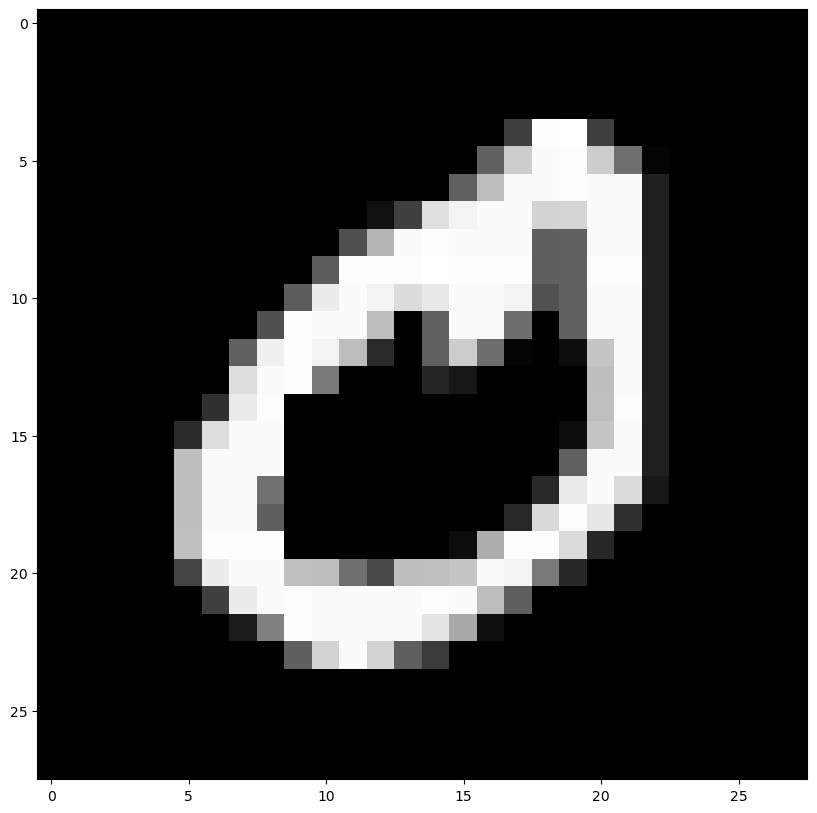

In [17]:
# Veri setinden örnekler yazdıralım.
plt.figure(figsize = (10,10))
plt.imshow(x_train[21], cmap = "gray")

In [24]:
# Bu olayı bir fonksiyona atayalım
def visualize_digits(data):
    plt.figure(figsize = (10, 10))
    for n in range(10): #ilk 10 rakam görselleştirilecek
        ax = plt.subplot(5, 5, n + 1)
        plt.imshow(data[n], cmap = "gray")
        #plt.axis("off")

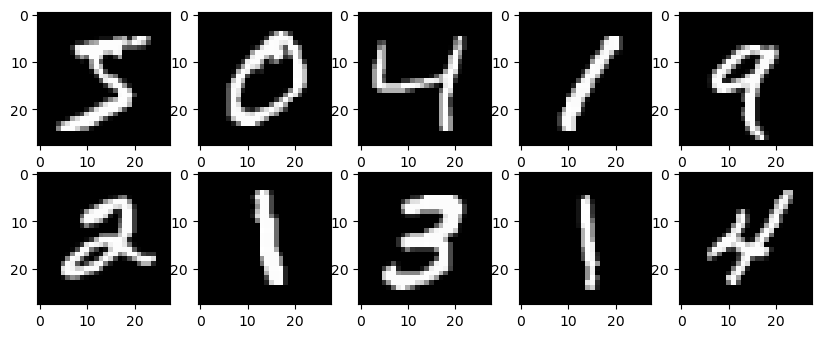

In [25]:
visualize_digits(x_train)

In [33]:
x_train[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

Normalde bizim .png veya .jpg formatında olan veri setimizdeki fotoğrafları yapay sinir ağı anlamaz. Fotoğraftaki piksellerin sayısal formatı üzerinden bir örüntü oluşturur ve bu şekilde model eğitilir. Yeni bir görsel tahmin için modele verildiğinde yapay sinir ağının oluşturduğu örüntü yani model sayesinde rakam tanınır.

In [35]:
def pixel_and_visualization(img):
    fig = plt.figure(figsize = (12, 12))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = "gray")
    width, height = img.shape

    threshold = img.max() / 2.5

    for x in range(width):
        for y in range(height):

            ax.annotate(str(round(img[x][y], 2)), xy= (y,x), color = "white" if img[x][y] < threshold else "black")

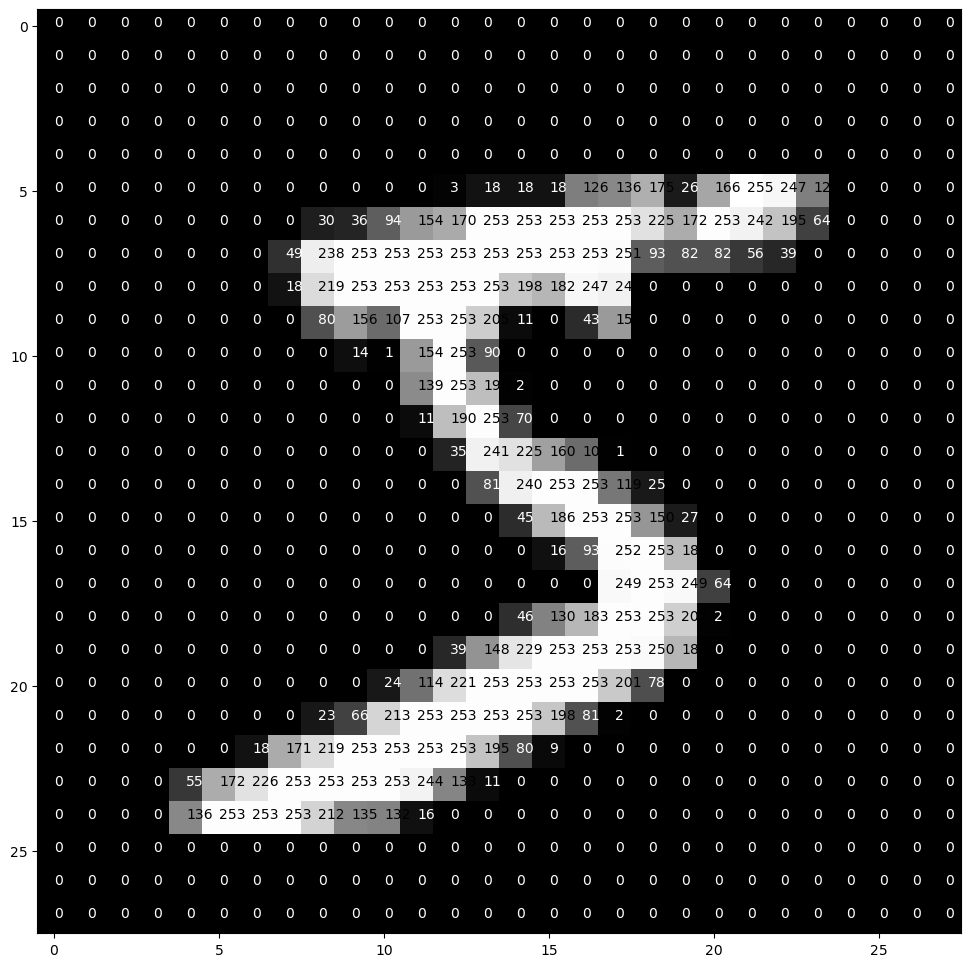

In [37]:
pixel_and_visualization(x_train[0])

# 3) Veriyi hazırlamak

# Encoding
Bağımlı değişkenimiz olan y değişkenini encode edeceğiz. <br>
- y_train önceki hali : [0 1 2 3 4 5 6 7 8 9]
- y_train sonraki hali (2 sınıfı için) : [ 0 0 1 0 0 0 0 0 0 0]

In [38]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [39]:
y_train[0:5] # Mesela ilk görselin sınıfı 5 miş

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

# Reshaping

Burada görsellerin pixel numaralarını yapay sinir ağına verebilmemiz için onlarını bir boyut olarak ekliyoruz.

In [47]:
print(f"x_train boyutu: {x_train.shape}")
print(f"x_test boyutu: {x_test.shape}")

x_train boyutu: (60000, 28, 28)
x_test boyutu: (10000, 28, 28)


In [49]:
x_train = x_train.reshape(x_train.shape[0], 28, 28,1)
x_test = x_test.reshape(x_test.shape[0], 28, 28,1)

In [51]:
print(f"x_train boyutu: {x_train.shape}")
print(f"x_test boyutu: {x_test.shape}")

x_train boyutu: (60000, 28, 28, 1)
x_test boyutu: (10000, 28, 28, 1)


In [60]:
x_train[2]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

# Standardization

Bu numerik pixel değerlerini 0-255 arasında değiş de 0-1 arasında ölçekliyoruz. Bu da modelin daha iyi ve kısa sürede eğitilebilmesini sağlayacak.

In [56]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# 4) Modelleme

## Sinir ağının mimarisini oluşturalım

In [67]:
model = Sequential([
    Flatten(input_shape = (28, 28, 1)),
    Dense(units = 128, activation= "relu", name = "hidden_layer_1"),
    Dense(units = num_labels, activation= "softmax", name = "output_layer")
])

model.compile(loss = "categorical_crossentropy", optimizer = "adam",
             metrics = [tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "accuracy"])

In [68]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Yapay sinir ağını oluşturduk. Şimdi kendi veri setimizi kullanarak modeli eğitelim.

In [69]:
model.fit(x_train, y_train, epochs= 10, batch_size = 128, validation_data=(x_test, y_test)) # 128'de bir ağırlıklar değişir.

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8363 - loss: 0.6043 - precision: 0.9289 - recall: 0.7065 - val_accuracy: 0.9438 - val_loss: 0.1959 - val_precision: 0.9581 - val_recall: 0.9318
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9469 - loss: 0.1855 - precision: 0.9607 - recall: 0.9357 - val_accuracy: 0.9572 - val_loss: 0.1488 - val_precision: 0.9653 - val_recall: 0.9498
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9626 - loss: 0.1279 - precision: 0.9709 - recall: 0.9554 - val_accuracy: 0.9661 - val_loss: 0.1159 - val_precision: 0.9729 - val_recall: 0.9607
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9713 - loss: 0.0985 - precision: 0.9770 - recall: 0.9657 - val_accuracy: 0.9690 - val_loss: 0.1047 - val_precision: 0.9748 - val_recall: 0.9649
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9773 - loss: 0.0806 - precision: 0.9810 - recall: 0.9730 - val_accuracy: 0.9734 - val_loss: 0.

# 5) Model Başarısını Değerlendirme (Evaluation)

In [70]:
history = model.fit(x_train, y_train, epochs= 10, batch_size = 128, validation_data= (x_test, y_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9939 - loss: 0.0255 - precision: 0.9948 - recall: 0.9927 - val_accuracy: 0.9764 - val_loss: 0.0766 - val_precision: 0.9789 - val_recall: 0.9754
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9943 - loss: 0.0229 - precision: 0.9949 - recall: 0.9936 - val_accuracy: 0.9795 - val_loss: 0.0692 - val_precision: 0.9818 - val_recall: 0.9780
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9955 - loss: 0.0193 - precision: 0.9963 - recall: 0.9947 - val_accuracy: 0.9810 - val_loss: 0.0659 - val_precision: 0.9836 - val_recall: 0.9802
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9971 - loss: 0.0145 - precision: 0.9976 - recall: 0.9968 - val_accuracy: 0.9783 - val_loss: 0.0713 - val_precision: 0.9806 - val_recall: 0.9772
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9966 - loss: 0.0145 - precision: 0.9970 - recall: 0.9961 - val_accuracy: 0.9787 - val_loss: 0.

Accuracy ve loss değerlerini daha iyi analiz edebilmek için grafiklere dökelim.

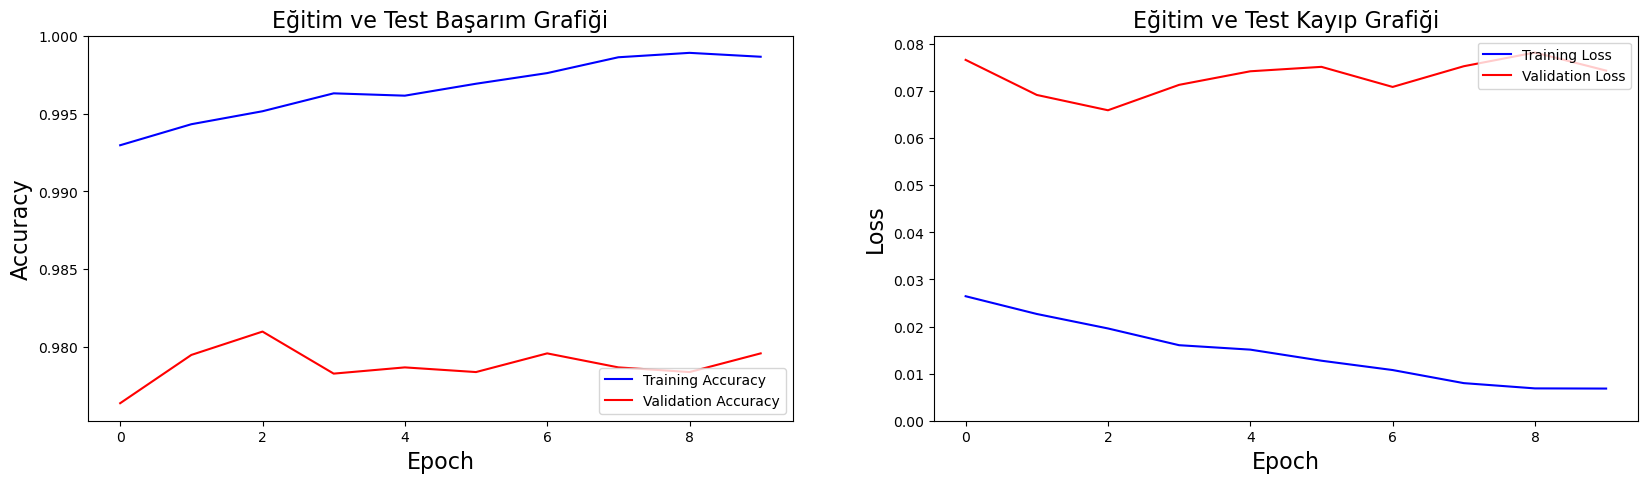

In [87]:
# Grafik 1: Accuracy
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], color = "b", label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], color = "r", label = "Validation Accuracy")
plt.legend(loc = "lower right")

plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Accuracy", fontsize = 16)
plt.ylim([min(plt.ylim()), 1])
plt.title("Eğitim ve Test Başarım Grafiği", fontsize = 16)



# Grafik 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], color = "b", label = "Training Loss")
plt.plot(history.history["val_loss"], color = "r", label = "Validation Loss")
plt.legend(loc = "upper right")

plt.xlabel("Epoch", fontsize = 16)
plt.ylabel("Loss", fontsize = 16)
plt.ylim([0, max(plt.ylim())])
plt.title("Eğitim ve Test Kayıp Grafiği", fontsize = 16)
plt.show()

In [88]:
model.save("mnist_model.h5")

In [89]:
model.save("mnist_model.keras")

Şimdi örnek bir tahmin yapalım.

In [114]:
import random

random = random.randint(0, x_test.shape[0])
random

181

In [115]:
test_image = x_test[random]

In [116]:
y_test[random]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

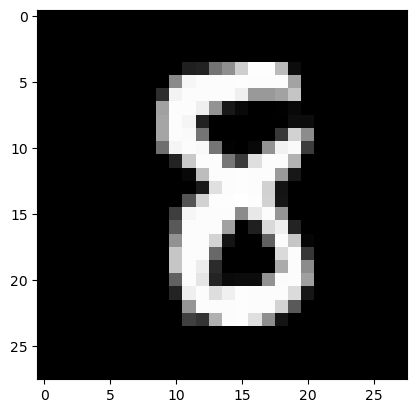

In [117]:
plt.imshow(test_image.reshape(28,28), cmap = "gray")

In [118]:
test_data = x_test[random].reshape(1,28,28,1)

In [119]:
probability = model.predict(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [120]:
probability

array([[7.2824837e-14, 3.9667766e-12, 1.8764446e-08, 8.2983441e-08,
        1.2224521e-15, 1.0586408e-07, 1.0150999e-09, 6.0492690e-16,
        9.9999976e-01, 2.7126308e-11]], dtype=float32)

In [121]:
predicted_classes = np.argmax(probability)
predicted_classes

8

Son olarak tahmini toparlarsak:

In [122]:
print(f"Tahmin edilen sınıf: {predicted_classes} \n")
print(f"Tahmin edilen sınıfın olasılık değeri: {(np.max(probability, axis = -1))[0]}\n")
print(f"Diğer sınıfların olasılık değerleri: \n {probability}")

Tahmin edilen sınıf: 8 

Tahmin edilen sınıfın olasılık değeri: 0.9999997615814209

Diğer sınıfların olasılık değerleri: 
 [[7.2824837e-14 3.9667766e-12 1.8764446e-08 8.2983441e-08 1.2224521e-15
  1.0586408e-07 1.0150999e-09 6.0492690e-16 9.9999976e-01 2.7126308e-11]]
